First 5 records:
          date     price  bedrooms  grade  has_basement  living_in_m2  \
0  2014-05-15  312000.0         2      2          True     138.42547   
1  2014-11-14  310000.0         2      2         False     105.90942   
2  2014-12-24  320000.0         2      2         False     117.98681   
3  2015-02-22  264500.0         2      3         False     151.43189   
4  2015-01-06  700000.0         3      2          True     341.88304   

   renovated  nice_view  perfect_condition  real_bathrooms  has_lavatory  \
0      False      False              False               2          True   
1      False      False              False               1          True   
2      False       True              False               1         False   
3      False      False              False               2          True   
4      False      False              False               3         False   

   single_floor  month  quartile_zone  
0         False      5              1  
1         Fa

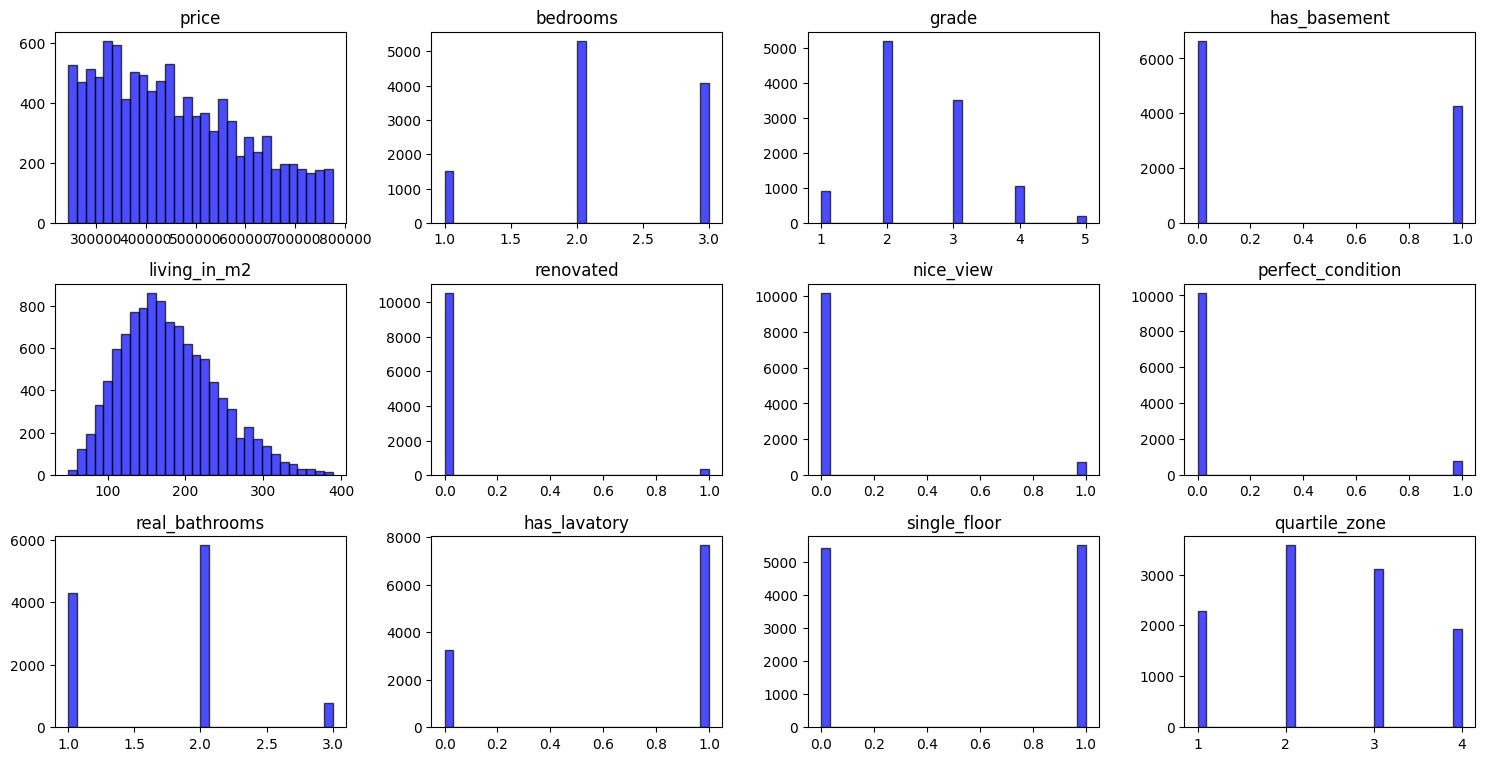


Final cleaned DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 10901 entries, 0 to 13602
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              10901 non-null  float64
 1   bedrooms           10901 non-null  int64  
 2   grade              10901 non-null  int64  
 3   has_basement       10901 non-null  int64  
 4   living_in_m2       10901 non-null  float64
 5   renovated          10901 non-null  int64  
 6   nice_view          10901 non-null  int64  
 7   perfect_condition  10901 non-null  int64  
 8   real_bathrooms     10901 non-null  int64  
 9   has_lavatory       10901 non-null  int64  
 10  single_floor       10901 non-null  int64  
 11  quartile_zone      10901 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 1.1 MB
None

First 5 records of cleaned DataFrame:
       price  bedrooms  grade  has_basement  living_in_m2  renovated  \
0  312000.0         2     

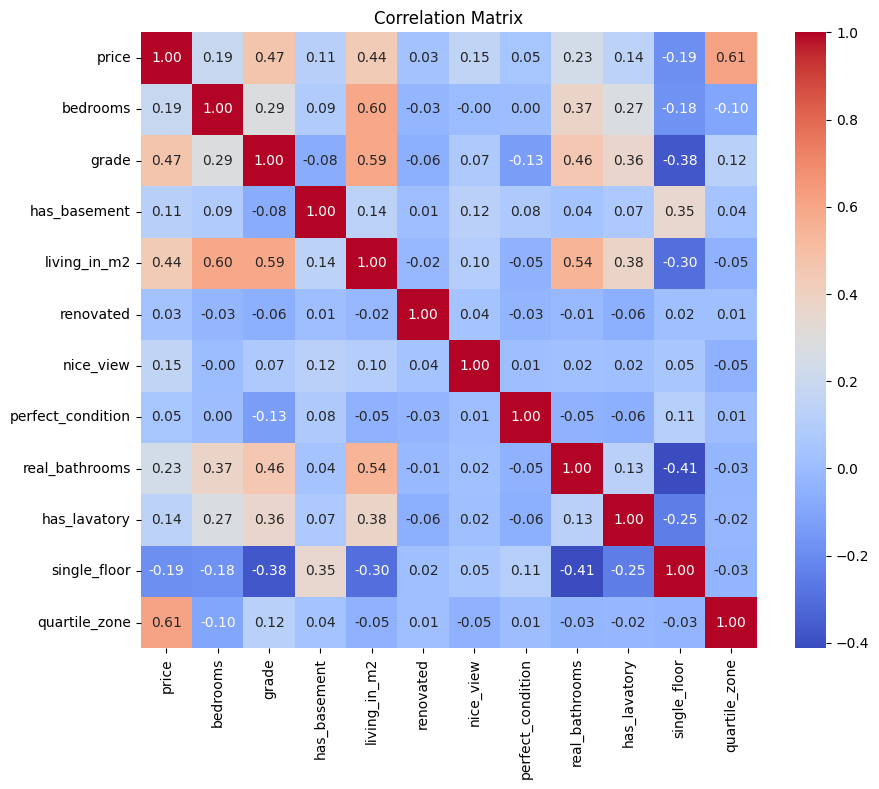

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Set the path to the file you'd like to load
file_path = "E:/Pruebas Python/IABD_PIA/Tema 03/Redes Neuronales/df_train.csv"

# Load the CSV with the correct encoding
df = pd.read_csv(file_path, encoding='utf-8', delimiter=',', decimal='.')

print("First 5 records:\n", df.head())

print("\nEDA Summary:")
print(df.describe())

print("\nMissing values per column:\n", df.isnull().sum())

print("\nData types:\n", df.dtypes)

print("\nDataFrame shape after deletion:", df.shape)

print("\nColumn names:", df.columns.tolist())

print("\nDeleting rows with any missing values...")
df = df.dropna()

print("\nDataFrame shape after deleting rows with missing values:", df.shape)

print("\nDeleting duplicate rows...")
df = df.drop_duplicates()

print("\nDataFrame shape after deleting duplicate rows:", df.shape)
    
print("\nData types after conversion:\n", df.dtypes)

print("\nDeleting date columns...")
date_columns = [col for col in df.columns if 'date' in col.lower() or 'month' in col.lower()]
df = df.drop(columns=date_columns)

print("\nDataFrame shape after datetime conversion:", df.shape)

print("\nDeleting outliers. Values less than 10% or more than 90% quantiles for 'price' column...")
if 'price' in df.columns:
    lower_bound = df['price'].quantile(0.10)
    upper_bound = df['price'].quantile(0.90)
    df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
    print("\nDataFrame shape after deleting outliers in 'price':", df.shape)
    
print("\nConverting boolean columns to integers...")
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)
    
print("\nPlotting hist plots for numeric columns...")
df.hist(bins=30, figsize=(15, 10), layout=(4, 4), color='blue', edgecolor='black', alpha=0.7, grid=False)
plt.tight_layout()
plt.show()

print("\nFinal cleaned DataFrame info:")
print(df.info())

print("\nFirst 5 records of cleaned DataFrame:\n", df.head())

print("\nData cleaning completed.")

print("\nMatrix of correlations:\n")
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()